In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print('Numpy version: ', np.__version__)

Numpy version:  2.4.6


In [2]:
df = sns.load_dataset('titanic')
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
pd.DataFrame({'missing': missing, 'missing_percent': missing_percent.round(2)}).sort_values(by='missing', ascending=False)

,missing,missing_percent
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


In [3]:
#Task o
#1. How many unique values in 'embarked'?
print('Unique EMbarked: ', df['embarked'].nunique())
#2. What is the most common passenger class?
print('Most frequent pclass: ', df['pclass'].mode()[0])

Unique EMbarked:  3
Most frequent pclass:  3


In [4]:
df2 = df.copy()
df2['age'] = df2['age'].fillna(df2['age'].mean())
df2['embarked'] = df2['embarked'].fillna(df2['embarked'].mode()[0])
df2 = df2.drop(columns=['deck'])

In [5]:
#Task 1: Find all male passengers who paid a fare of above 200 and survived
print('Task 1')
print(df2[(df2['sex']=='male') & (df2['alive']=='yes')])
#Task 2: eUsing .iloc extract rows 100 to 109 and the last 3 columns
print()
print('Task 2')
print(df2.iloc[100:110, -3:])

Task 1
     survived  pclass   sex        age  sibsp  parch     fare embarked  \
17          1       2  male  29.699118      0      0  13.0000        S   
21          1       2  male  34.000000      0      0  13.0000        S   
23          1       1  male  28.000000      0      0  35.5000        S   
36          1       3  male  29.699118      0      0   7.2292        C   
55          1       1  male  29.699118      0      0  35.5000        S   
..        ...     ...   ...        ...    ...    ...      ...      ...   
838         1       3  male  32.000000      0      0  56.4958        S   
839         1       1  male  29.699118      0      0  29.7000        C   
857         1       1  male  51.000000      0      0  26.5500        S   
869         1       3  male   4.000000      1      1  11.1333        S   
889         1       1  male  26.000000      0      0  30.0000        C   

      class    who  adult_male  embark_town alive  alone  
17   Second    man        True  Southampton  

In [6]:
#Task 3: Mean fare for each embark town
print(df2.groupby('embark_town')['fare'].mean())
#Task 4: Survivor count sorted by Class
print(df2[df2['alive']=='yes'].groupby('pclass').size().sort_values(ascending=False))

embark_town
Cherbourg      59.954144
Queenstown     13.276030
Southampton    27.079812
Name: fare, dtype: float64
pclass
1    136
3    119
2     87
dtype: int64


In [7]:
#Task 5: Merging Embarkment Port Full names with codes
port_lookup = pd.DataFrame({'embarked':['C', 'Q', 'S'], 'full_name': ['Chebourg', 'Queenstown', 'Southampton']})
df_merged = df2.merge(port_lookup, on='embarked', how='left')
print('Task 5')
print(df_merged[['embarked', 'full_name']].drop_duplicates())
print(df_merged.head())

Task 5
  embarked    full_name
0        S  Southampton
1        C     Chebourg
5        Q   Queenstown
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone    full_name  
0    man        True  Southampton    no  False  Southampton  
1  woman       False    Cherbourg   yes  False     Chebourg  
2  woman       False  Southampton   yes   True  Southampton  
3  woman       False  Southampton   yes  False  Southampton  
4    man        True  Southampton    no   True  Southampton  


*Graph Tasks*

In [8]:
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

df = sns.load_dataset('titanic').dropna(subset=['age', 'embarked'])
df['age_group'] = pd.cut(df['age'], bins=[0,12,18,35,60,120], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
print("DF Shape: ", df.shape)


DF Shape:  (712, 16)


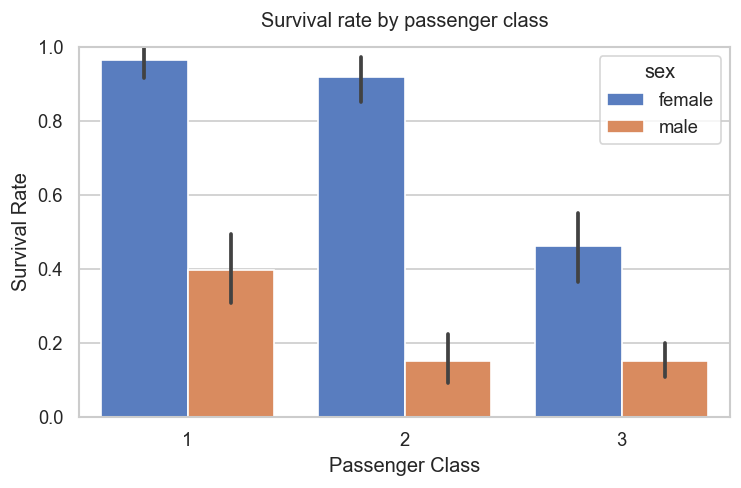

In [9]:
fig,ax = plt.subplots(figsize=(7,4))
#Task 1: Bar Plot
sns.barplot(data=df, x='pclass', hue='sex', y='survived')
ax.set_title('Survival rate by passenger class', pad=12)
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0,1)
plt.savefig('graph task 1.png')
plt.show()

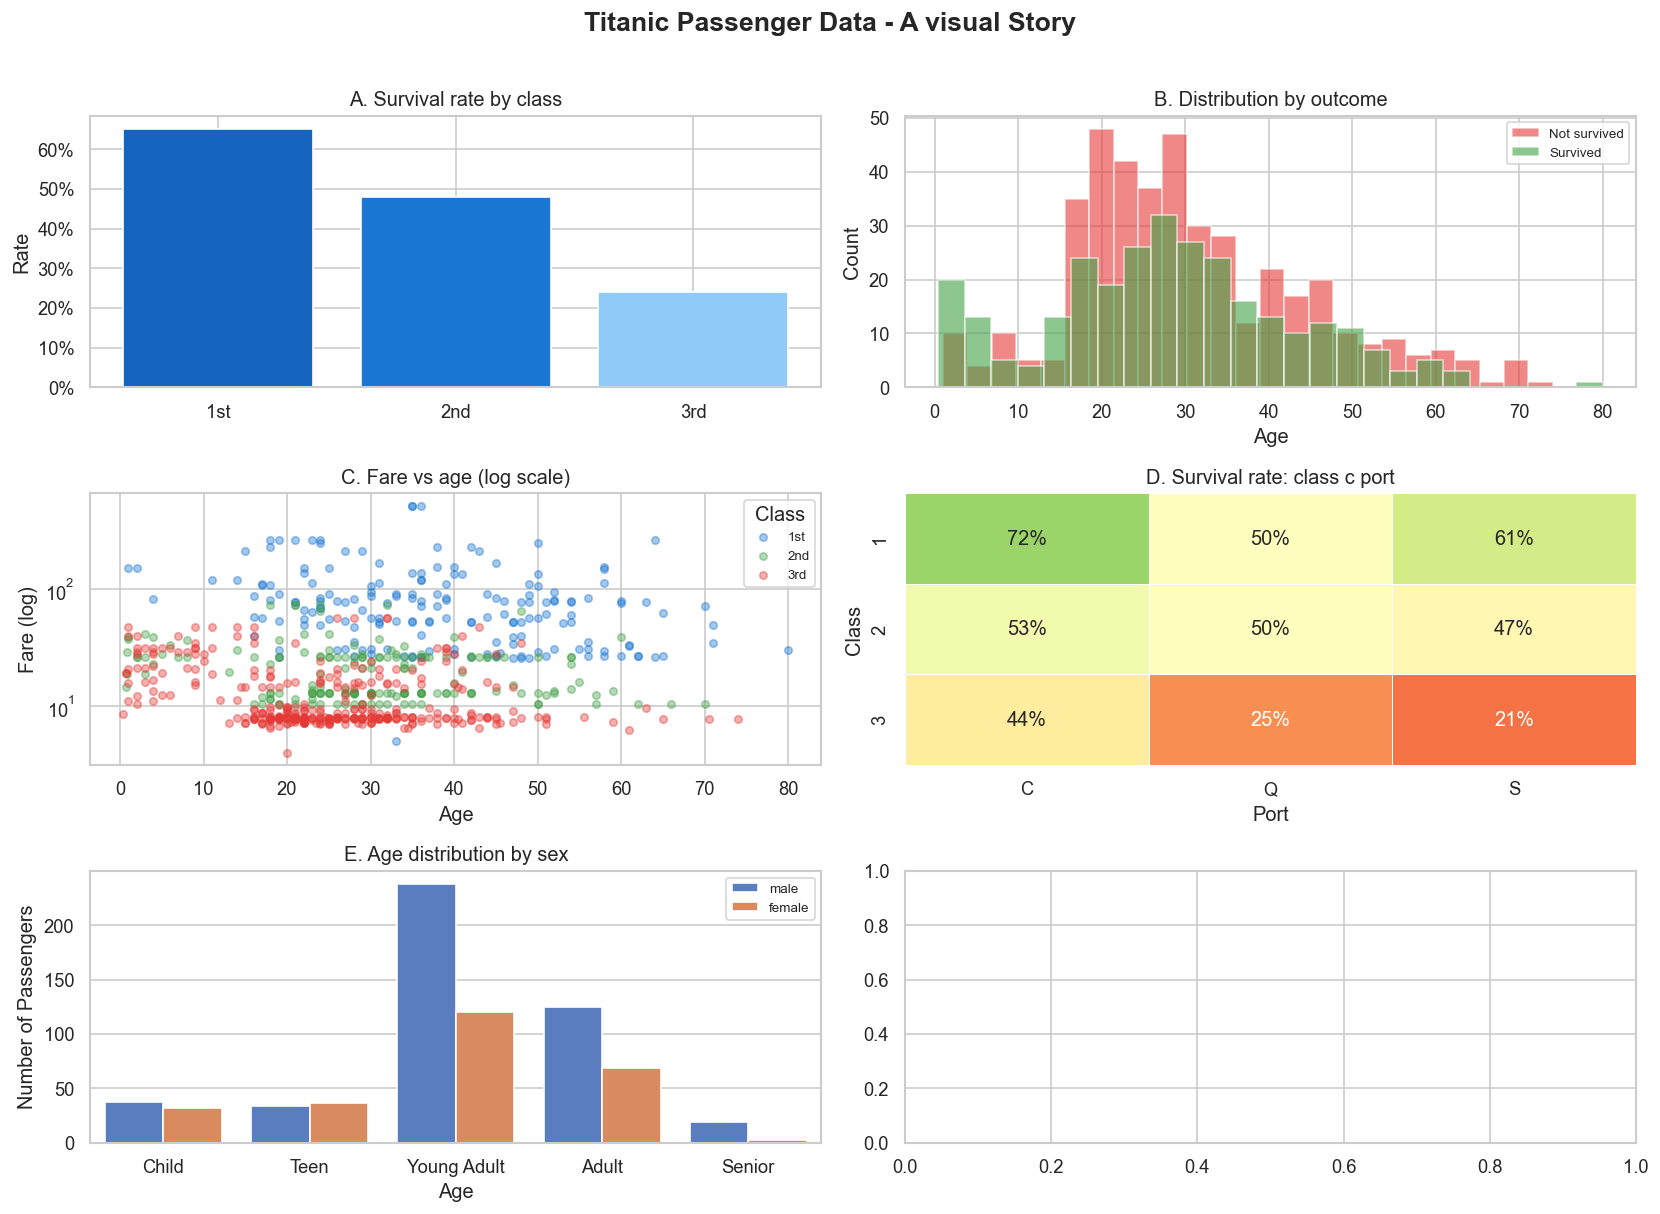

In [10]:
#Task 2: Dashboard
fig,axes = plt.subplots(3, 2, figsize=(14,10))
fig.suptitle('Titanic Passenger Data - A visual Story', fontsize=16, fontweight='bold', y=1.01)
ax = axes[0,0]
surv = df.groupby('pclass')['survived'].mean()
ax.bar(['1st', '2nd', '3rd'], surv.values, color=['#1565C0', '#1976D2', '#90CAF9'])
ax.set_title('A. Survival rate by class')
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))

ax = axes[0,1]
ax.hist(df[df['survived']==0]['age'], bins=25, alpha=0.6, color='#E53935', label='Not survived')
ax.hist(df[df['survived']==1]['age'], bins=25, alpha=0.6, color='#43A047', label='Survived')
ax.set_title('B. Distribution by outcome')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

ax = axes[1,0]
for cls, c, lbl in zip([1,2,3], ['#1976D2', '#43A047', '#E53935'],['1st', '2nd', '3rd']):
    s = df[df['pclass']==cls]
    ax.scatter(s['age'], s['fare'], c=c, alpha=0.4, s=20, label=lbl)
ax.set_yscale('log')
ax.set_title('C. Fare vs age (log scale)')
ax.set_xlabel('Age')
ax.set_ylabel('Fare (log)')
ax.legend(title='Class', fontsize=8)

ax = axes[1,1]
pivot = df.pivot_table(values='survived', index='pclass', columns='embarked', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', linewidth=0.5, ax=ax, vmin=0, vmax=1, cbar=False)
ax.set_title('D. Survival rate: class c port')
ax.set_xlabel('Port')
ax.set_ylabel('Class')

ax = axes[2,0]
sns.countplot(data=df, x='age_group', hue='sex', ax=ax)
ax.set_title('E. Age distribution by sex')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Passengers')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('titanic_dashboard.png')
plt.show()